In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Load dataset

iris = load_iris()

# Convert to dataframe

df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# Use only petal length and petal width

df = df[['petal length (cm)', 'petal width (cm)']]

print("Using only petal features:")
print(df.head())

Using only petal features:
   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


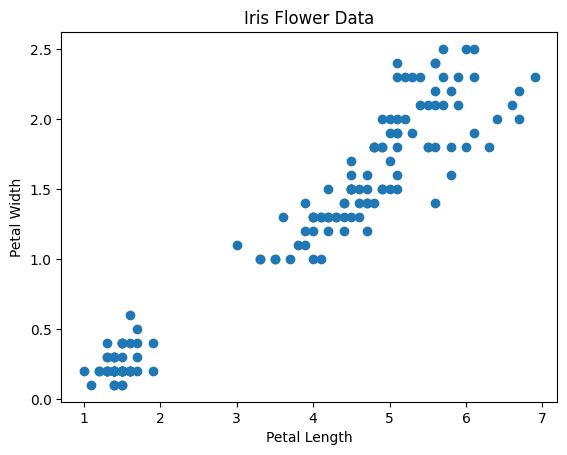

In [5]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Data")

plt.show()

In [6]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print(df_scaled.head())

   petal length (cm)  petal width (cm)
0           0.067797          0.041667
1           0.067797          0.041667
2           0.050847          0.041667
3           0.084746          0.041667
4           0.067797          0.041667


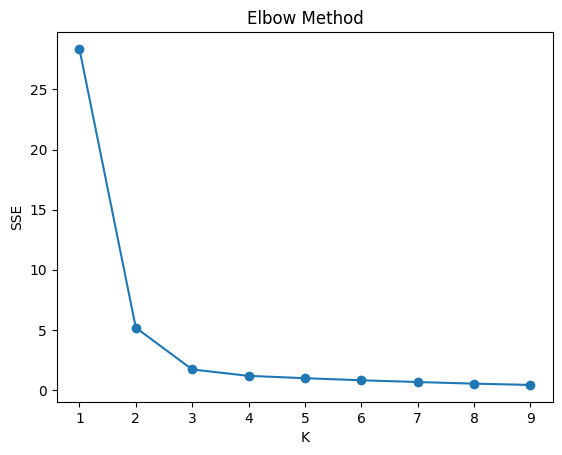

In [7]:
sse = []

for k in range(1,10):
    
    km = KMeans(n_clusters=k)
    km.fit(df_scaled)
    
    sse.append(km.inertia_)

plt.plot(range(1,10), sse, marker='o')

plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Method")

plt.show()

In [8]:
km = KMeans(n_clusters=3)

y_predicted = km.fit_predict(df_scaled)

df['Cluster'] = y_predicted

print(df.head())

   petal length (cm)  petal width (cm)  Cluster
0                1.4               0.2        1
1                1.4               0.2        1
2                1.3               0.2        1
3                1.5               0.2        1
4                1.4               0.2        1


In [9]:
centers = km.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[0.7740113  0.81510417]
 [0.07830508 0.06083333]
 [0.55867014 0.51041667]]


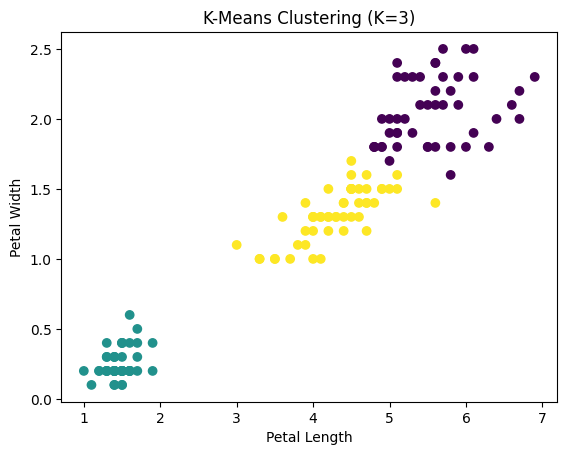

In [10]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['Cluster'])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering (K=3)")

plt.show()